# Parameter sweeps

Run thousands of bubbles at once. `jax.vmap` simulates a row of bubbles of different sizes in one call, and `GridSweep` maps the response over a grid of radius, frequency, and pressure on every CPU core. The map is checked against linear resonance theory, collected batch by batch, saved to a NumPy file, and drawn from that file.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import tempfile
import time
from pathlib import Path

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jbubble import SaveSpec, run_simulation, solve_eom
from jbubble.utils import GridSweep
from jbubble.utils.presets import free_bubble

plt.style.use("jbubble.style.light")
DRIVE_COLOUR = "#8c959f"  # the light theme's neutral grey for the drive

# JBUBBLE_QUICK=1 shrinks the sweeps for continuous integration (CI).
QUICK = os.environ.get("JBUBBLE_QUICK", "0") == "1"

## A row of bubbles with `jax.vmap`

Write a function that simulates one bubble, then let `jax.vmap` run it for a whole array of equilibrium radii. Every bubble feels the same 20 kPa, 1 MHz tone burst, so only the bubbles near resonance at 1 MHz respond strongly. `jax.jit` compiles the batched function once.

In [2]:
FREQ = 1e6  # drive frequency [Hz]
P_ROW = 20e3  # drive amplitude [Pa]
CYCLES = 8


def radius_trace(R0):
    eom, pulse = free_bubble(R0=R0, freq=FREQ, pressure=P_ROW, cycle_num=CYCLES)
    result = run_simulation(eom, pulse, save_spec=SaveSpec(num_samples=800))
    return result.ts, result.radius / R0, result.driving_pressure


row = jax.jit(jax.vmap(radius_trace))

radii = jnp.linspace(1e-6, 6e-6, 64 if QUICK else 256)
t0 = time.perf_counter()
ts, ratio, drive = jax.block_until_ready(row(radii))
t_first = time.perf_counter() - t0
t0 = time.perf_counter()
jax.block_until_ready(row(radii))
t_again = time.perf_counter() - t0
print(f"{radii.size} bubbles: {t_first:.1f} s with compilation, {t_again:.2f} s after")

256 bubbles: 3.0 s with compilation, 0.29 s after


Linear theory predicts the resonance. For a gas bubble with polytropic exponent $\kappa$ and surface tension $\sigma$, small oscillations ring at

$$
f_0 = \frac{1}{2\pi R_0}\sqrt{\frac{1}{\rho_L}
    \left[3\kappa\left(P_\text{amb} + \frac{2\sigma}{R_0}\right)
    - \frac{2\sigma}{R_0}\right]},
$$

the Minnaert frequency with a surface-tension correction. The values below are the `free_bubble` preset's defaults.

In [3]:
KAPPA, SIGMA, P_AMB, RHO_L = 1.4, 0.072, 101325.0, 998.0


def linear_resonance(R0):
    """Return the linear resonance frequency [Hz] of a free bubble of radius R0 [m]."""
    stiffness = 3 * KAPPA * (P_AMB + 2 * SIGMA / R0) - 2 * SIGMA / R0
    return np.sqrt(stiffness / RHO_L) / (2 * np.pi * R0)


# Radius whose linear resonance is the drive frequency, by bisection on f0(R0).
lo, hi = 1e-6, 6e-6
for _ in range(60):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if linear_resonance(mid) > FREQ else (lo, mid)
R_res = 0.5 * (lo + hi)

peak = np.asarray(ratio.max(axis=1))
R_peak = float(radii[np.argmax(peak)])
print(f"Linear theory: resonant radius at 1 MHz = {R_res * 1e6:.2f} µm")
print(f"Simulation:    largest response at R0   = {R_peak * 1e6:.2f} µm")

Linear theory: resonant radius at 1 MHz = 3.73 µm
Simulation:    largest response at R0   = 3.57 µm


The simulated peak sits a few percent below the linear prediction. Viscous and radiation damping lower the frequency of the largest response, and at $R_\max/R_0 \approx 1.5$ the oscillation is already mildly nonlinear, which lowers it further.

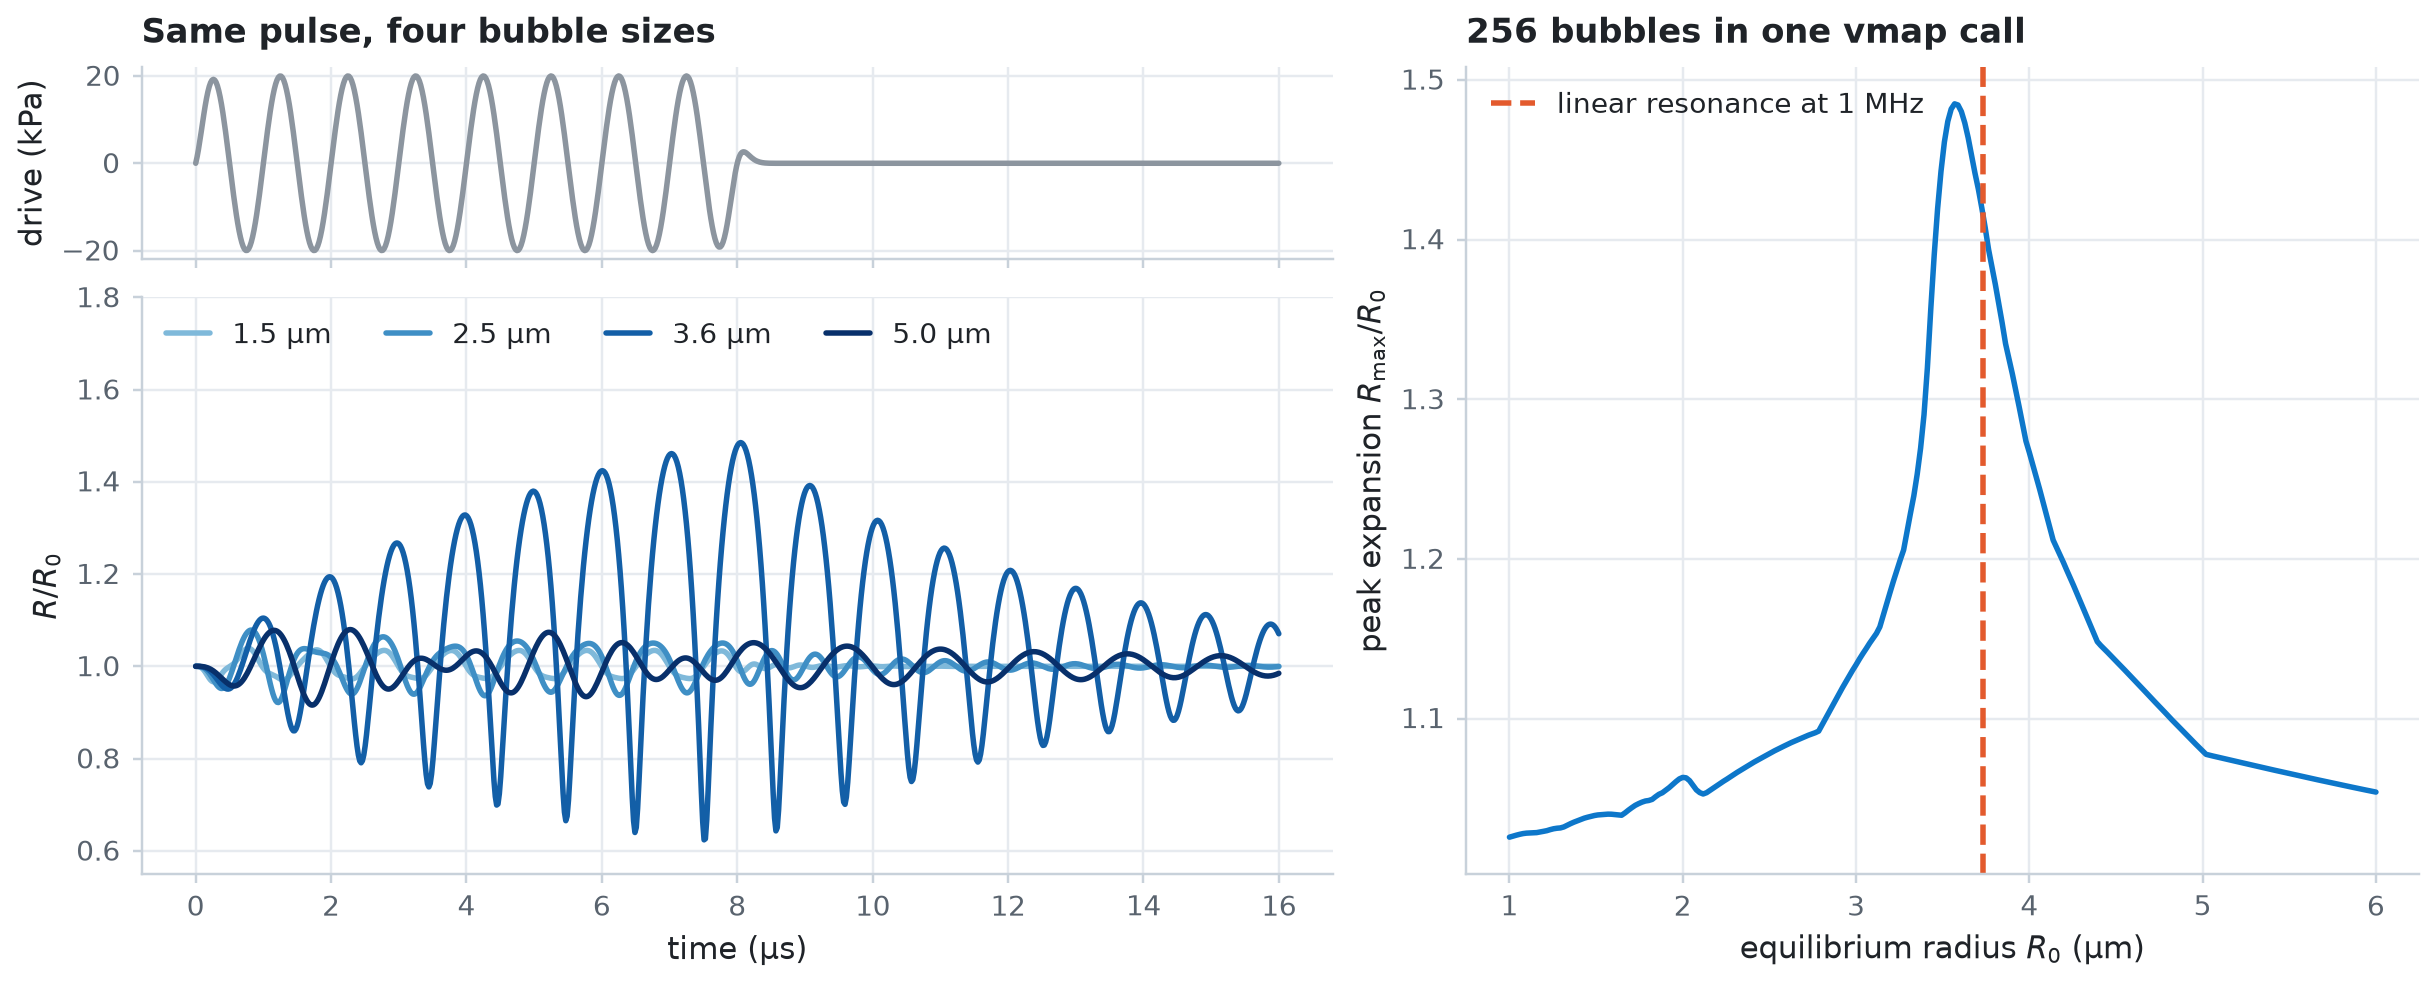

In [4]:
show = [1.5e-6, 2.5e-6, R_peak, 5e-6]  # four radii to draw over time
idx = [int(np.argmin(np.abs(np.asarray(radii) - r))) for r in show]
cmap = plt.colormaps[plt.rcParams["image.cmap"]]
shades = [cmap(x) for x in np.linspace(0.45, 1.0, len(idx))]

fig = plt.figure(figsize=(11, 4.4), layout="constrained")
grid = fig.add_gridspec(2, 2, height_ratios=[1, 3], width_ratios=[1.25, 1])
ax_drive = fig.add_subplot(grid[0, 0])
ax_r = fig.add_subplot(grid[1, 0], sharex=ax_drive)
ax_peak = fig.add_subplot(grid[:, 1])

t_us = np.asarray(ts[0]) * 1e6
ax_drive.plot(t_us, np.asarray(drive[0]) / 1e3, color=DRIVE_COLOUR)
ax_drive.set_ylabel("drive (kPa)")
ax_drive.tick_params(labelbottom=False)
ax_drive.set_title("Same pulse, four bubble sizes")
for i, shade in zip(idx, shades, strict=True):
    ax_r.plot(
        t_us, np.asarray(ratio[i]), color=shade, label=f"{float(radii[i]) * 1e6:.1f} µm"
    )
ax_r.set_xlabel("time (µs)")
ax_r.set_ylabel("$R/R_0$")
ax_r.set_ylim(0.55, 1.8)
ax_r.legend(loc="upper left", ncols=4)

ax_peak.plot(np.asarray(radii) * 1e6, peak, color="C0")
ax_peak.axvline(R_res * 1e6, color="C1", ls="--", label="linear resonance at 1 MHz")
ax_peak.set_xlabel("equilibrium radius $R_0$ (µm)")
ax_peak.set_ylabel("peak expansion $R_\\max/R_0$")
ax_peak.set_title(f"{radii.size} bubbles in one vmap call")
ax_peak.legend(loc="upper left")
plt.show()

## A response map with `GridSweep`

`GridSweep` evaluates a function on the Cartesian product of named parameter axes. It compiles `jax.vmap` of the function once and runs chunks of the grid on all CPU cores at the same time.

Return more than the metric. A batch under `jax.vmap` runs until its slowest member finishes, and a solve that reaches `max_steps` stops early, so return `converged` and the solver's step count as well, and mask the points that didn't converge. `solve_eom` gives both, through `sol.result` and `sol.stats`.

In [5]:
def response(R0, freq, pressure):
    eom, pulse = free_bubble(R0=R0, freq=freq, pressure=pressure, cycle_num=CYCLES)
    sol = solve_eom(eom, pulse, save_spec=SaveSpec(num_samples=512))
    return {
        "expansion": jnp.max(sol.ys.R) / R0,
        "converged": diffrax.is_successful(sol.result),
        "num_steps": sol.stats["num_steps"],
    }


n = 40 if QUICK else 120
search_space = {
    "R0": jnp.linspace(1e-6, 6e-6, n),
    "freq": jnp.linspace(0.5e6, 5e6, n),
    "pressure": jnp.array([20e3, 150e3]),
}
# The default progress=True shows a progress bar; this sweep takes seconds.
sweep = GridSweep(response, search_space, progress=False)
print(
    f"{sweep.total_points} simulations on a {sweep.grid_shape} grid, "
    f"{sweep.workers} workers, {sweep.num_batches} batches"
)

28800 simulations on a (120, 120, 2) grid, 4 workers, 57 batches


## Collect batches, save, then load

`GridSweep.run` returns the whole grid at once. For a sweep too large for memory, iterate over `GridSweep.batches` instead: each batch holds the parameter values and outputs of up to `batch_size` grid points, in grid order. Here the batches are collected into flat columns, written to one `.npz` file with `np.savez`, and read back with `np.load`.

In [6]:
columns: dict[str, list[np.ndarray]] = {}
t0 = time.perf_counter()
for params, outputs in sweep.batches():
    for name, values in {**params, **outputs}.items():
        columns.setdefault(name, []).append(values)
t_sweep = time.perf_counter() - t0
table = {name: np.concatenate(chunks) for name, chunks in columns.items()}
print(f"Sweep finished in {t_sweep:.1f} s")

with tempfile.TemporaryDirectory() as tmp:
    path = Path(tmp) / "response_map.npz"
    np.savez(path, **table)
    print(f"Wrote {path.name}: {path.stat().st_size / 1e3:.0f} kB")
    with np.load(path) as npz:
        arrays = dict(npz)

# The axes are in sorted order of name, and the last varies fastest.
loaded = {name: values.reshape(sweep.grid_shape) for name, values in arrays.items()}
print("Arrays:", ", ".join(sorted(loaded)), "| axes:", list(sweep.axes))
steps = loaded["num_steps"]
print(
    f"Converged: {loaded['converged'].sum()} of {loaded['converged'].size}; "
    f"steps per solve: min {steps.min()}, median {int(np.median(steps))}, "
    f"max {steps.max()}"
)

Sweep finished in 16.7 s
Wrote response_map.npz: 1182 kB
Arrays: R0, converged, expansion, freq, num_steps, pressure | axes: ['R0', 'freq', 'pressure']
Converged: 28800 of 28800; steps per solve: min 133, median 260, max 2792


Draw the map from the loaded file. At 20 kPa the ridge of strong response follows the linear resonance curve $f_0(R_0)$. At 150 kPa the bubble is nonlinear: the main ridge broadens and leans to lower frequencies, and new ridges appear, such as the subharmonic resonance near $2f_0$, where the bubble oscillates at half the drive frequency.

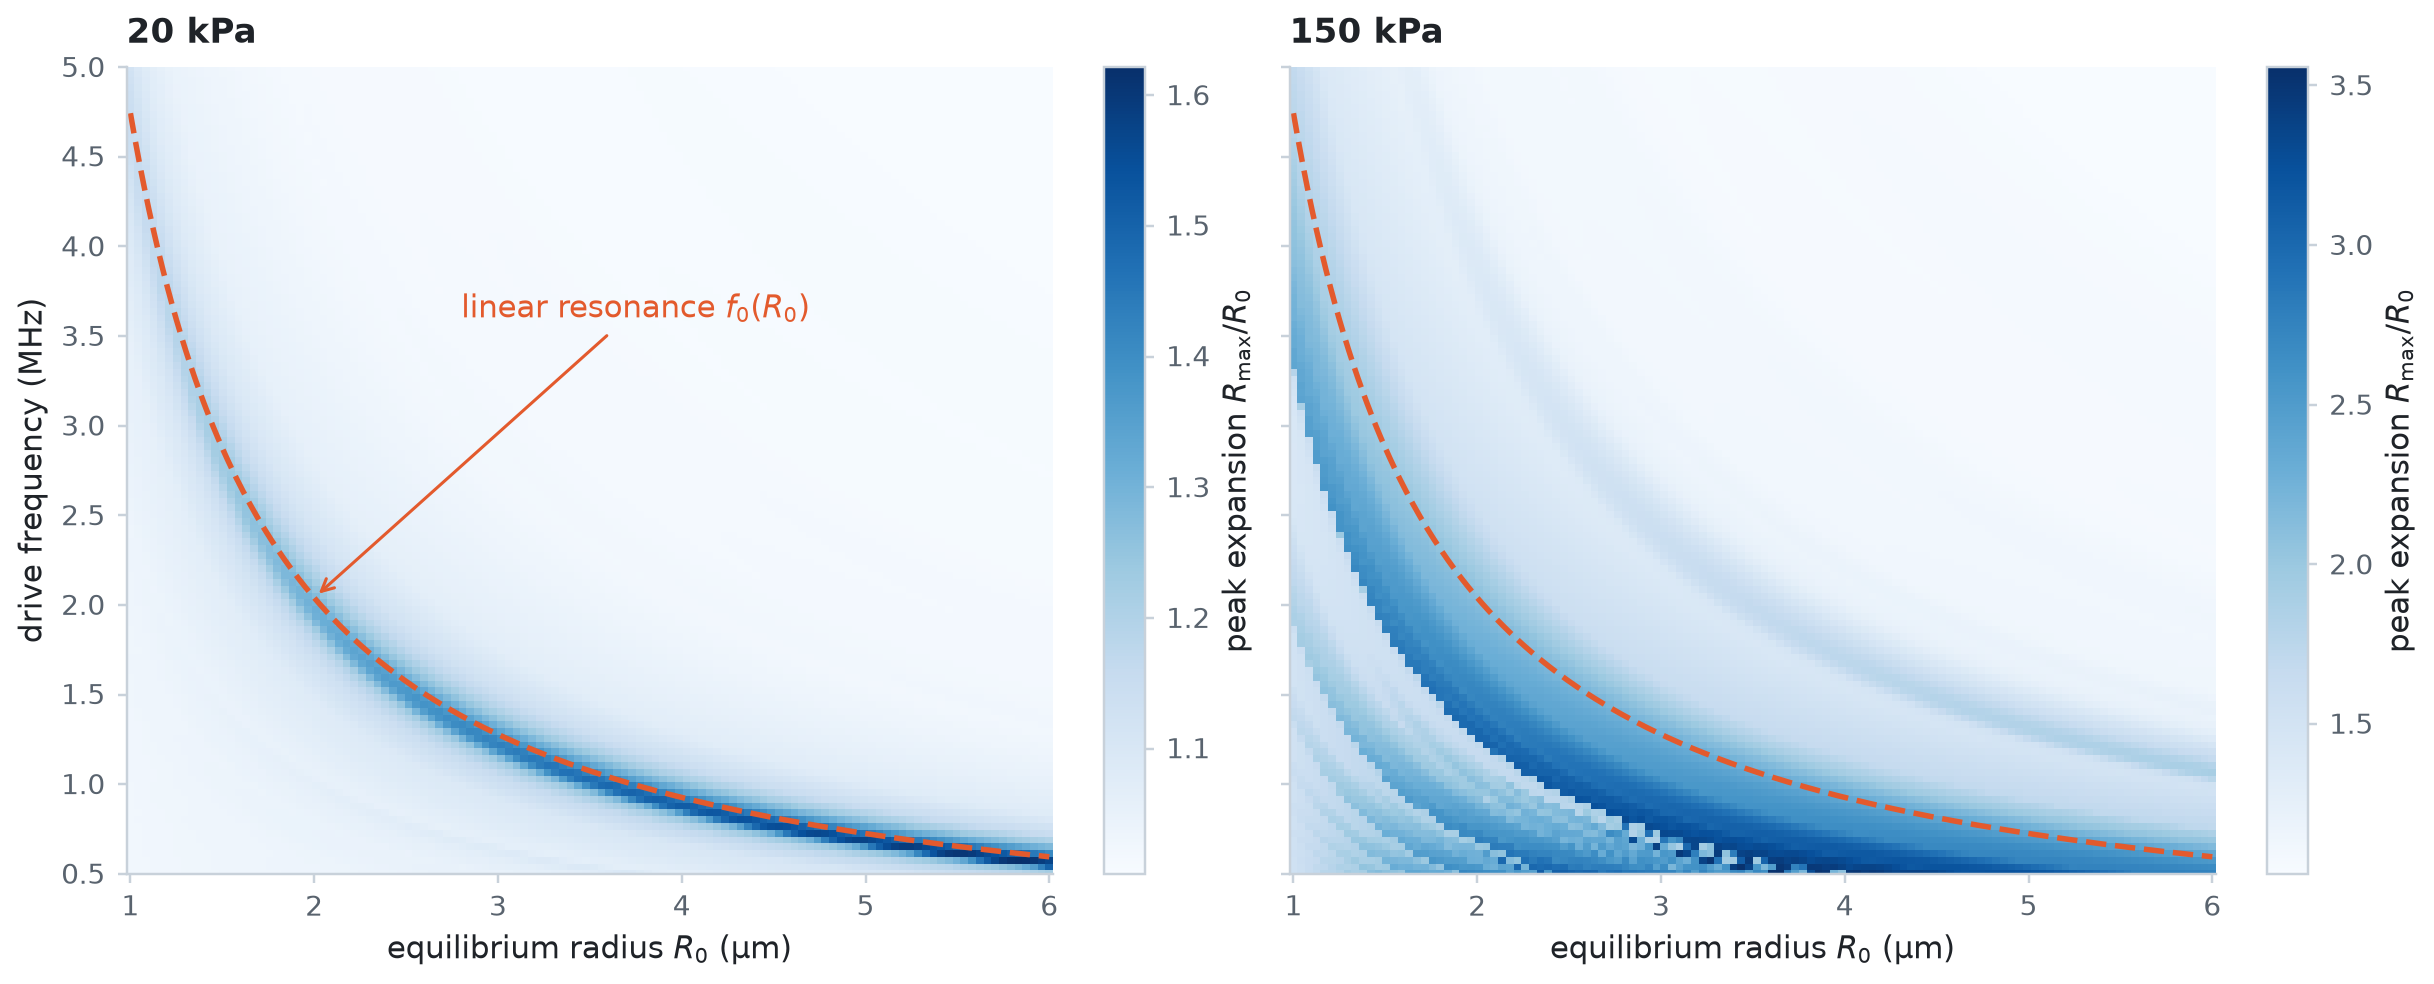

In [7]:
expansion = np.where(loaded["converged"], loaded["expansion"], np.nan)
R0_axis = np.asarray(search_space["R0"])
f_axis = np.asarray(search_space["freq"])
R_fine = np.linspace(R0_axis[0], R0_axis[-1], 400)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), layout="constrained", sharey=True)
for k, ax in enumerate(axes):
    mesh = ax.pcolormesh(
        R0_axis * 1e6, f_axis / 1e6, expansion[:, :, k].T, shading="nearest"
    )
    fig.colorbar(mesh, ax=ax, label="peak expansion $R_\\max/R_0$")
    ax.plot(R_fine * 1e6, linear_resonance(R_fine) / 1e6, color="C1", ls="--")
    ax.set_ylim(f_axis[0] / 1e6, f_axis[-1] / 1e6)
    ax.set_xlabel("equilibrium radius $R_0$ (µm)")
    ax.set_title(f"{float(search_space['pressure'][k]) / 1e3:.0f} kPa")
axes[0].set_ylabel("drive frequency (MHz)")
axes[0].annotate(
    "linear resonance $f_0(R_0)$",
    xy=(2.0, linear_resonance(2e-6) / 1e6),
    xytext=(2.8, 3.6),
    color="C1",
    arrowprops={"arrowstyle": "->", "color": "C1"},
)
plt.show()